<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


=== Respondent Distribution by Industry ===
Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Higher Education                                890
Transportation, or Supply Chain                 859
Computer Systems Design and Services            844
Energy                                          578
Insurance                                       389
Name: count, dtype: int64


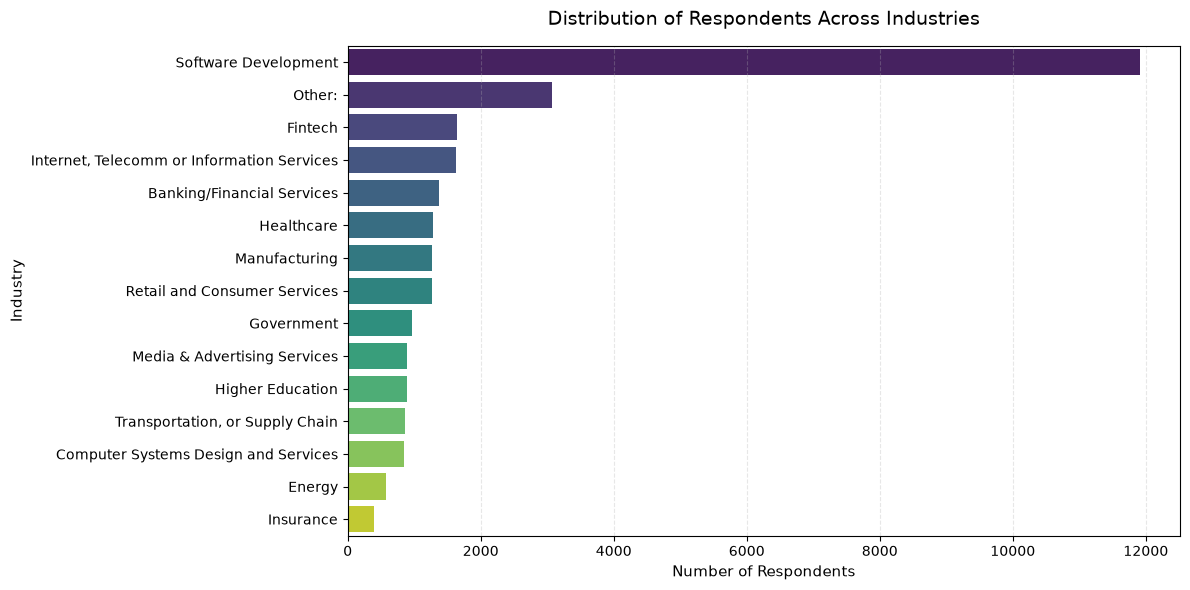

In [4]:
##Write your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the value counts for the Industry column
industry_counts = df['Industry'].value_counts()
print("=== Respondent Distribution by Industry ===")
print(industry_counts)

# 2. Plot a clean horizontal bar chart with explicit hue mapping to eliminate warnings
plt.figure(figsize=(12, 6))
sns.barplot(
    x=industry_counts.values, 
    y=industry_counts.index, 
    hue=industry_counts.index, 
    palette='viridis', 
    legend=False
)

plt.title('Distribution of Respondents Across Industries', fontsize=14, pad=15)
plt.xlabel('Number of Respondents', fontsize=11)
plt.ylabel('Industry', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [5]:
##Write your code here
import pandas as pd

# 1. Calculate basic statistics for yearly compensation
mean_comp = df['ConvertedCompYearly'].mean()
median_comp = df['ConvertedCompYearly'].median()
std_comp = df['ConvertedCompYearly'].std()

print("=== Compensation Basic Statistics ===")
print(f"Mean Compensation:   ${mean_comp:,.2f}")
print(f"Median Compensation: ${median_comp:,.2f}")
print(f"Std Deviation:       ${std_comp:,.2f}\n")

# 2. Define the threshold for outliers (3 standard deviations above the mean)
outlier_threshold = mean_comp + (3 * std_comp)
print(f"Outlier Threshold (Mean + 3*Std): ${outlier_threshold:,.2f}\n")

# 3. Filter and count the high compensation outliers
outliers_df = df[df['ConvertedCompYearly'] > outlier_threshold]
print(f"Number of high compensation outliers detected: {len(outliers_df)}")

=== Compensation Basic Statistics ===
Mean Compensation:   $86,155.29
Median Compensation: $65,000.00
Std Deviation:       $186,756.97

Outlier Threshold (Mean + 3*Std): $646,426.21

Number of high compensation outliers detected: 89


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


=== IQR Outlier Detection ===
25th Percentile (Q1): $32,712.00
75th Percentile (Q3): $107,971.50
IQR:                  $75,259.50
Lower Bound:          $-80,177.25
Upper Bound:          $220,860.75

Number of outliers detected using IQR method: 978


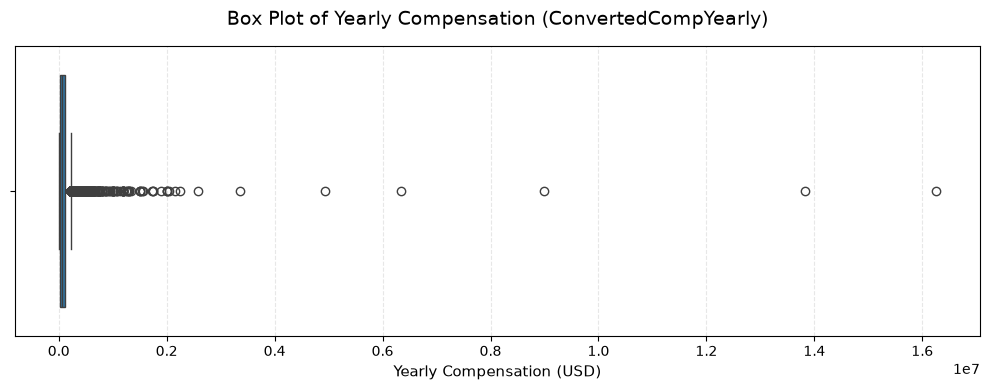

In [6]:
##Write your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Drop rows missing compensation data so we have a clean sample
df_iqr = df.dropna(subset=['ConvertedCompYearly']).copy()

# 2. Calculate Q1, Q3, and IQR
Q1 = df_iqr['ConvertedCompYearly'].quantile(0.25)
Q3 = df_iqr['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

# 3. Determine the upper and lower bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("=== IQR Outlier Detection ===")
print(f"25th Percentile (Q1): ${Q1:,.2f}")
print(f"75th Percentile (Q3): ${Q3:,.2f}")
print(f"IQR:                  ${IQR:,.2f}")
print(f"Lower Bound:          ${lower_bound:,.2f}")
print(f"Upper Bound:          ${upper_bound:,.2f}\n")

# 4. Count the outliers
outliers = df_iqr[(df_iqr['ConvertedCompYearly'] < lower_bound) | (df_iqr['ConvertedCompYearly'] > upper_bound)]
print(f"Number of outliers detected using IQR method: {len(outliers)}")

# 5. Visualize outliers using a box plot
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_iqr['ConvertedCompYearly'], color='#1f77b4')

plt.title('Box Plot of Yearly Compensation (ConvertedCompYearly)', fontsize=14, pad=15)
plt.xlabel('Yearly Compensation (USD)', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [7]:
##Write your code here
# 1. Filter out rows where ConvertedCompYearly falls outside the IQR bounds
# We keep values that are between the lower_bound and upper_bound (or are NaN if you want to preserve them, 
# but usually we filter the non-null records)
df_no_outliers = df_iqr[(df_iqr['ConvertedCompYearly'] >= lower_bound) & (df_iqr['ConvertedCompYearly'] <= upper_bound)].copy()

# 2. Validate the size of the new DataFrame
original_clean_count = len(df_iqr)
new_count = len(df_no_outliers)
removed_count = original_clean_count - new_count

print("=== DataFrame Outlier Removal Validation ===")
print(f"Original rows (with compensation data): {original_clean_count}")
print(f"New rows (excluding outliers):          {new_count}")
print(f"Rows successfully removed:               {removed_count}")

=== DataFrame Outlier Removal Validation ===
Original rows (with compensation data): 23435
New rows (excluding outliers):          22457
Rows successfully removed:               978


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


=== Correlation Matrix ===
                     Age_Numeric  YearsCodePro  ConvertedCompYearly  JobSat
Age_Numeric               1.0000        0.8231               0.3688  0.0670
YearsCodePro              0.8231        1.0000               0.3872  0.1002
ConvertedCompYearly       0.3688        0.3872               1.0000  0.0752
JobSat                    0.0670        0.1002               0.0752  1.0000

Generating heatmap...


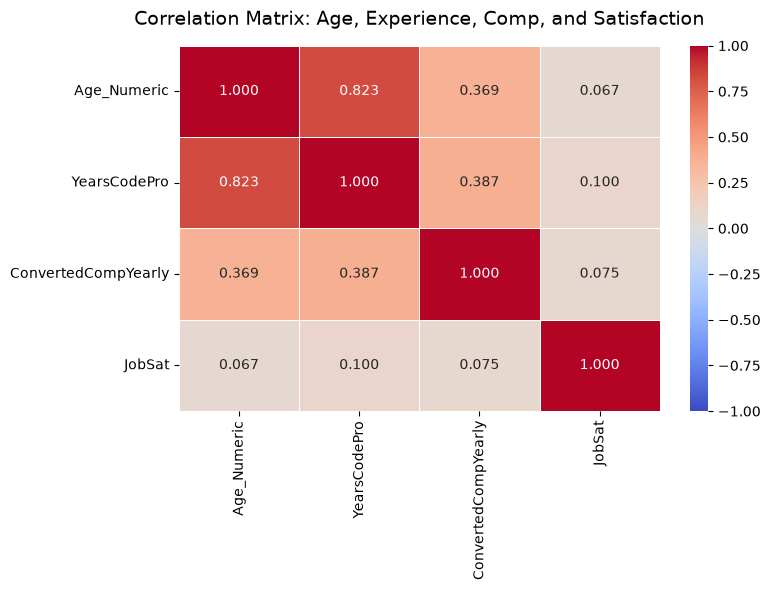

In [8]:
##Write your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a clean copy of our outlier-removed DataFrame
df_corr_analysis = df_no_outliers.copy()

# 2. Map the Age column string brackets to approximate numeric midpoints
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 68
}
df_corr_analysis['Age_Numeric'] = df_corr_analysis['Age'].map(age_mapping)

# 3. Ensure other target columns are numeric for the matrix calculation
df_corr_analysis['YearsCodePro'] = pd.to_numeric(df_corr_analysis['YearsCodePro'], errors='coerce')
df_corr_analysis['JobSat'] = pd.to_numeric(df_corr_analysis['JobSat'], errors='coerce')

# 4. Select the numeric columns we want to correlate
numeric_cols = ['Age_Numeric', 'YearsCodePro', 'ConvertedCompYearly', 'JobSat']
correlation_matrix = df_corr_analysis[numeric_cols].corr()

print("=== Correlation Matrix ===")
print(correlation_matrix.round(4))
print("\nGenerating heatmap...")

# 5. Visualize the matrix using a Seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".3f", 
    linewidths=0.5, 
    vmin=-1, 
    vmax=1
)

plt.title('Correlation Matrix: Age, Experience, Comp, and Satisfaction', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
